In [ ]:
!pip install sentence-transformers seaborn matplotlib scikit-learn

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
sentences = [
    # Cricket (5)
    "The batsman scored a century in the final match",
    "The bowler delivered a perfect yorker to take a wicket",
    "Fielders saved crucial runs near the boundary",
    "The team celebrated their victory after a thrilling chase",
	"Team India won the T20 worldcup this year",

    # Cooking (4)
	"Cooking is the process of preparing food by combining ingredients and applying heat or other techniques",
    "The chef prepared a delicious pasta with fresh ingredients",
    "Baking requires precise measurements and temperature control",
    "The recipe includes spices that enhance the flavor of the dish",

    # Cybersecurity (3)
    "Strong passwords help protect systems from unauthorized access",
    "Encryption ensures that data remains secure during transmission",
    "Firewalls monitor network traffic and block malicious activity"
]

In [ ]:
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)

print("Embedding shape:", embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding shape: (12, 384)


In [ ]:

similarity_matrix = cosine_similarity(embeddings)

print("Similarity Matrix Shape:", similarity_matrix.shape)

Similarity Matrix Shape: (12, 12)


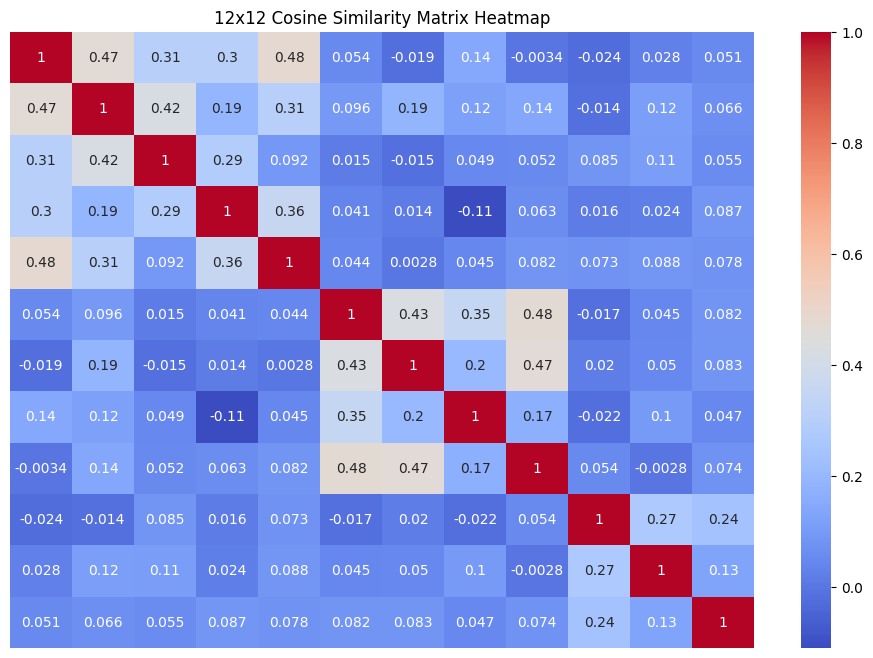

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(similarity_matrix, annot=True, cmap='coolwarm', xticklabels=False, yticklabels=False)
plt.title("12x12 Cosine Similarity Matrix Heatmap")
plt.show()

In [ ]:
query = "The bowler took three wickets in one over"

query_embedding = model.encode([query])

similarities = cosine_similarity(query_embedding, embeddings)[0]

# Get top 2 similar sentences
top_indices = np.argsort(similarities)[-2:][::-1]

print("Query:", query)
print("\nTop 2 similar sentences:\n")

for idx in top_indices:
    print(f"Sentence: {sentences[idx]}")
    print(f"Similarity Score: {similarities[idx]:.4f}\n")

Query: The bowler took three wickets in one over

Top 2 similar sentences:

Sentence: The bowler delivered a perfect yorker to take a wicket
Similarity Score: 0.6836

Sentence: The batsman scored a century in the final match
Similarity Score: 0.5707

